In [ ]:
# this notebook compares the interfish distances between the empirical data and a Gaussian distribution centered at the mean for each day with the corresponding standard deviation
import glob
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np

from cross_group_functions import crossing_times
from gaussian_sampling import gaussian_sample_generator

In [ ]:
cam_names = [
    "cam01-bear_outflow",
    "cam07-grass_outflow",
    "cam0610-big_outflow",
    "cam09-trail_outflow",
]
# dates = ["2025-08-07", "2025-08-10"]

In [3]:
all_rl = []
all_null = []
for cam in cam_names:
    tracks_folder = f"/project/uwyo-0003/salmon-tlc/processing/tracks-with-true-times_06-18-2026/{cam}"
    tracks_files = sorted(glob.glob(os.path.join(tracks_folder, "*.pkl")))
    all_rl.append([])
    all_null.append([])
    for j, tracks_file in enumerate([tracks_files[3], tracks_files[6]]):
        tracks = pickle.load(open(tracks_file, "rb"))
        lr = crossing_times(tracks, 1250, True)
        rl = crossing_times(tracks, 1250, False)
        for tag, lr_times in lr.items():
            if tag in rl:
                rl_times = rl[tag]
                if min(lr_times) < min(rl_times) and max(lr_times) > max(rl_times):
                    rl.pop(tag)
        all_rl[-1].append(rl)
        random_rl = gaussian_sample_generator(rl)
        all_null[-1].append(random_rl)

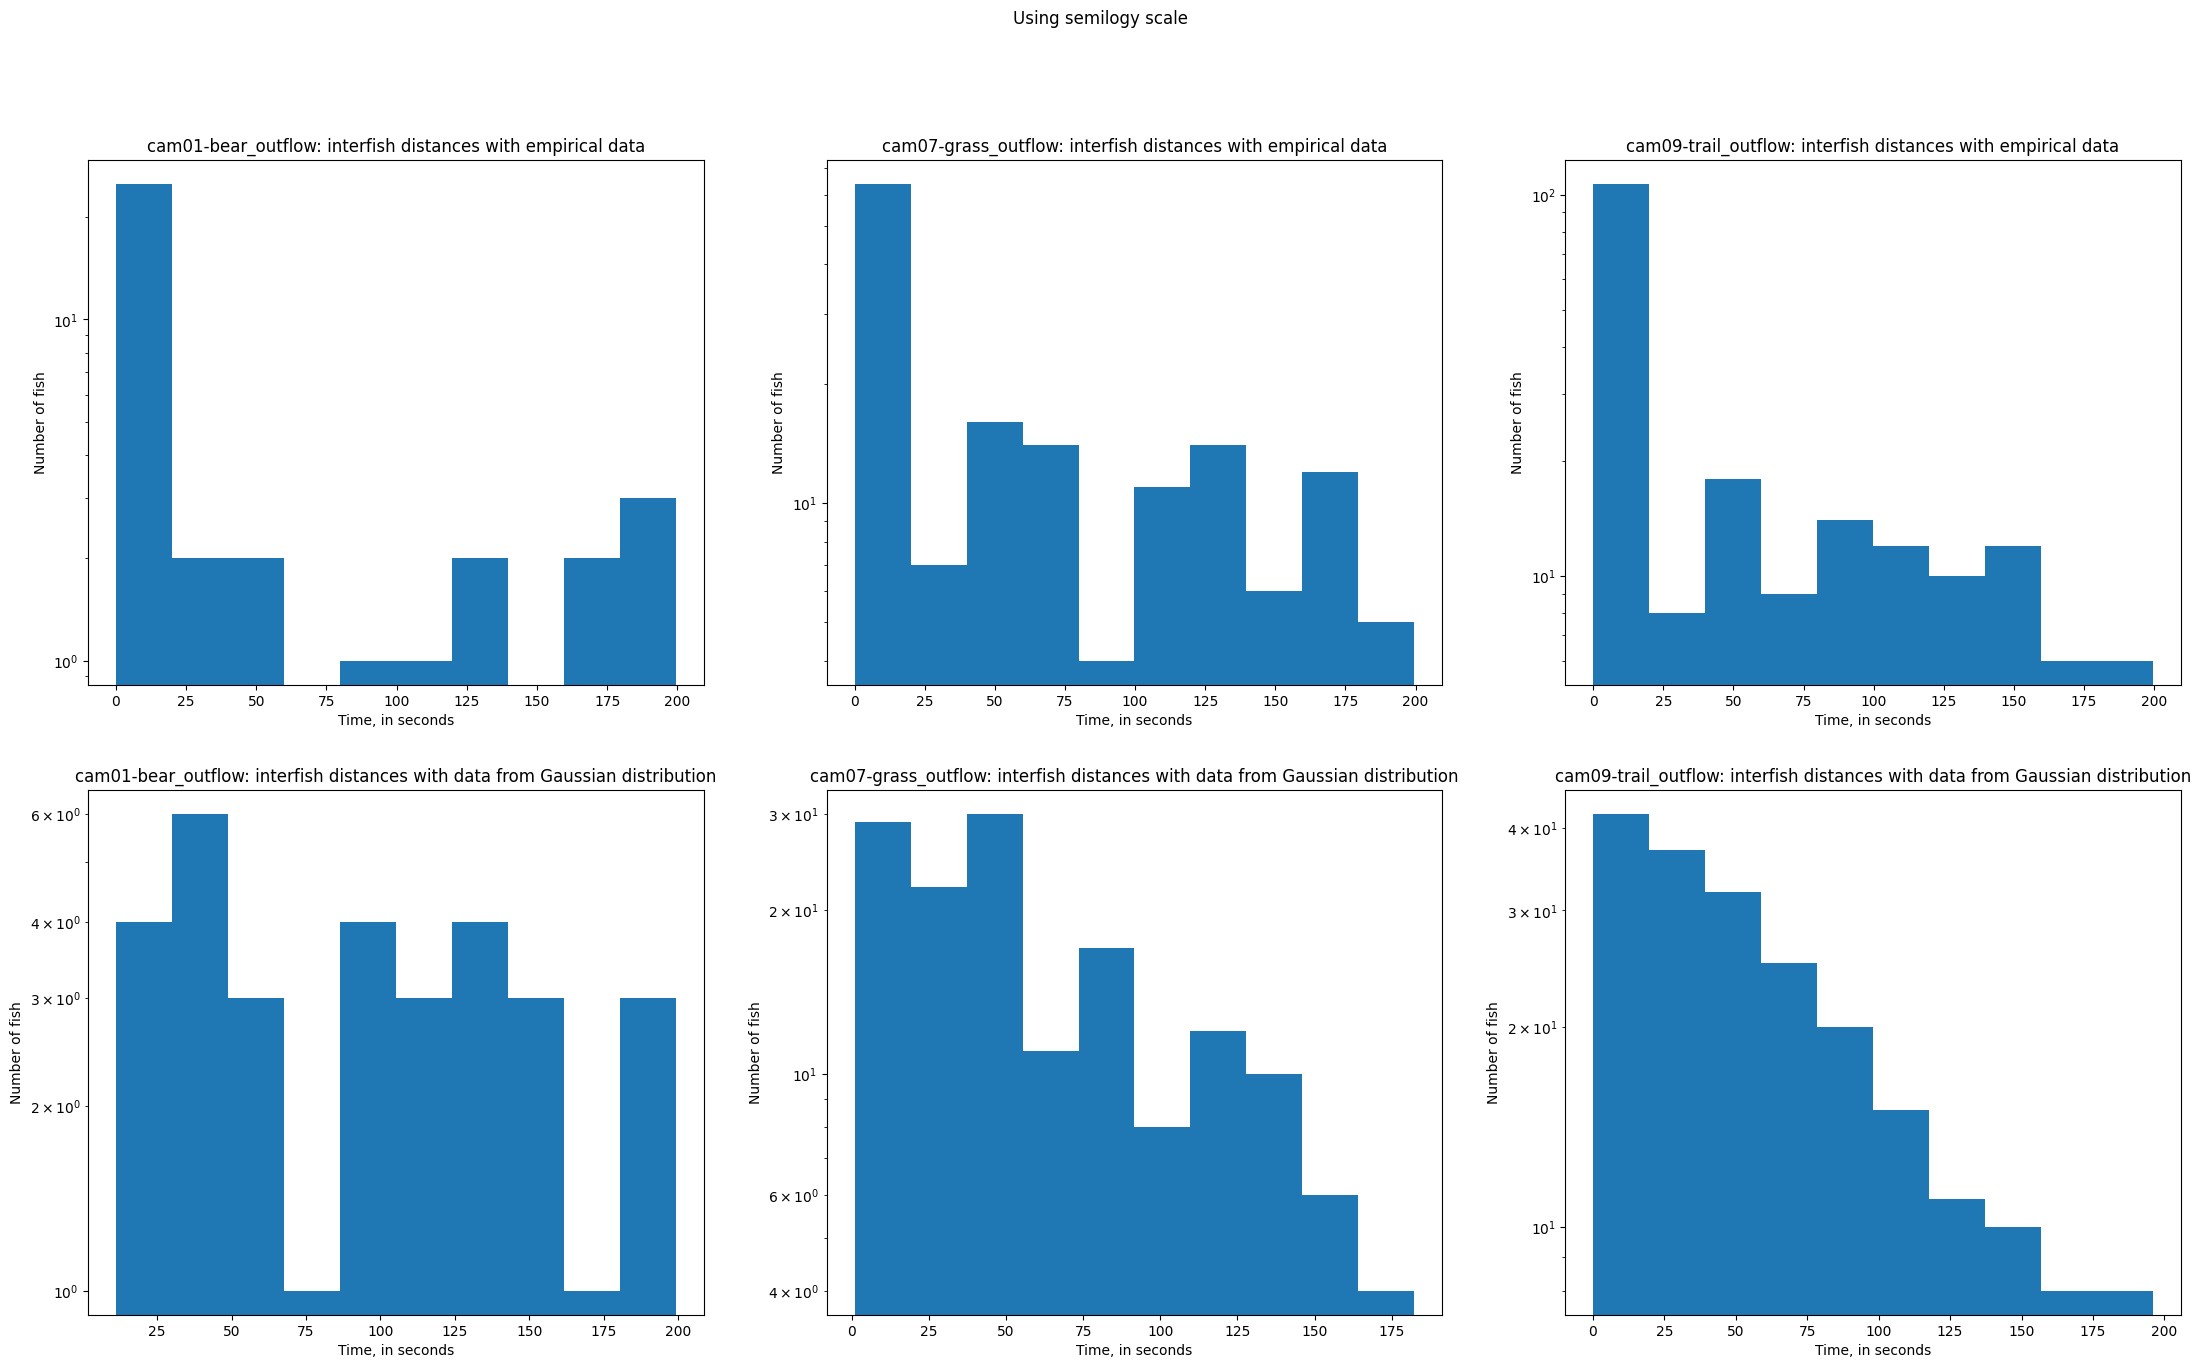

In [ ]:
fig = plt.figure(figsize=(27, 15))
for i, cam in enumerate(cam_names):
    true_interfish_distances = []
    for rl in all_rl[i]:
        all_tags = list(rl)
        # next_fish_distance = []
        for j, tag in enumerate(all_tags):
            if j == len(rl) - 1:
                continue
            distances = []
            for time1 in rl[tag]:
                for time2 in rl[all_tags[j + 1]]:
                    distances.append(abs(time1 - time2))
            true_interfish_distances.append(min(distances))
            # next_fish_distance.append(min(distances))
        # interfish_distances += nextfish
    true_interfish_distances = np.array(true_interfish_distances)
    ax = fig.add_subplot(2, 3, i + 1, yscale="log")

    # without log scales:
    ax.hist(true_interfish_distances[true_interfish_distances <= 200])

    # with log scales:
    # _, bins = np.histogram(true_interfish_distances[true_interfish_distances > 0])
    # logbins = np.logspace(np.log10(bins[0]), np.log10(bins[-1]), len(bins))
    # ax.hist(true_interfish_distances[true_interfish_distances > 0], bins = logbins)
    # ax.set_xlim(5 * 10 **(-2), 4 * 10 ** 4)

    ax.set_xlabel("Time, in seconds")
    ax.set_ylabel("Number of fish")
    ax.set_title(f"{cam}: interfish distances with empirical data")

    random_interfish_distances = []
    for null_rl in all_null[i]:
        # null_times = [time[0] for time in null_rl.values()]
        # null_times = sorted(null_times)
        # for j, time in enumerate(null_times):
        #     if j == len(null_times) - 1:
        #         continue
        #     random_interfish_distances.append(abs(time - null_times[j + 1]))
        all_tags_null = list(null_rl)
        for j, tag in enumerate(all_tags_null):
            if j == len(null_rl) - 1:
                continue
            distances = []
            for time1 in null_rl[tag]:
                for time2 in null_rl[all_tags_null[j + 1]]:
                    distances.append(abs(time1 - time2))
            random_interfish_distances.append(min(distances))
    random_interfish_distances = np.array(random_interfish_distances)
    ax = fig.add_subplot(2, 3, i + 4, yscale="log")

    # without log scales:
    ax.hist(random_interfish_distances[random_interfish_distances <= 200])

    # with log scales:
    # _, bins = np.histogram(random_interfish_distances[random_interfish_distances > 0])
    # logbins = np.logspace(np.log10(bins[0]), np.log10(bins[-1]), len(bins))
    # ax.hist(random_interfish_distances[random_interfish_distances > 0], bins=logbins)
    # ax.set_xlim(5 * 10 **(-2), 4 * 10 ** 4)

    ax.set_xlabel("Time, in seconds")
    ax.set_ylabel("Number of fish")
    ax.set_title(f"{cam}: interfish distances with data from Gaussian distribution")
fig.suptitle("Using semilogy scale")
plt.savefig("gauss-empirical_semilogy_interfish_distances.jpg", dpi=300)
plt.show()